In [77]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec

In [78]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [79]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [80]:
# # get names of all images in dataset_dir/images
# image_names = os.listdir(f"{DATASET_DIR}/images")

# count_images = len(image_names)

In [81]:
# count_images

In [82]:
# # sort image names based on number in name name format is : image_number.png
# image_names.sort(key=lambda x: int(x.split(".")[0].split("_")[1]))

In [83]:
# image_names[-5:]

In [84]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [85]:
# data["Label"].value_counts()

In [86]:
# data.tail()

In [87]:
# train_data = data.groupby("Label").sample(5000, random_state=42)
# train_data.head()

In [88]:
# train_data_index = train_data.index
# train_data_index

In [89]:
# remaining_data = data[~data.index.isin(train_data_index)]
# remaining_data.head()

In [90]:
# remaining_data["Label"].value_counts()

In [91]:
# # get data for validation and test
# # test data size should be 10k
# val_data = remaining_data.groupby("Label").sample(5000, random_state=42)

# val_data_index = val_data.index

# val_data["Label"].value_counts()

In [92]:
# test_data = remaining_data[~remaining_data.index.isin(val_data_index)]

# test_data["Label"].value_counts()

In [93]:
# def clean_image_path(image_path):
#     return os.path.basename(image_path)

# # store images and labels in a dataframe
# def store_images_and_labels(data_index, bin_labels, datatype):
#     images = []
#     labels = []

#     images_dir = f"{DATASET_DIR}/images"

#     for index in data_index:
#         image_path = f"{images_dir}/image_{index}.png"
#         images.append(image_path)
#         labels.append(bin_labels[index])

#     df = pd.DataFrame({
#         "Image": images,
#         "Label": labels
#     })


#     df["Image"] = df["Image"].apply(clean_image_path)

#     df.to_csv(f"{DATASET_DIR}/{datatype}.csv", index=False)

#     return df

# # images = []
# # labels = []

# # images_dir = f"{DATASET_DIR}/images"

# # with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
# #     all_labels = pickle.load(f)

# # for index in train_data_index:
# #     # images are grayscale, with mode L
# #     image_path = f"{images_dir}/image_{index}.png"
# #     images.append(image_path)
# #     labels.append(all_labels[index])


# # train_df = pd.DataFrame({
# #     "Image": images,
# #     "Label": labels
# # })


# with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
#     all_labels = pickle.load(f)

# data_labels = data["Label"]

# train_df = store_images_and_labels(train_data_index, data_labels, "train_multi")

In [94]:
# val_df = store_images_and_labels(val_data_index, data_labels, "val_multi")
# test_df = store_images_and_labels(test_data.index, data_labels, "test_multi")

In [95]:
train_df = pd.read_csv(f"{DATASET_DIR}/train_multi.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val_multi.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test_multi.csv")

In [96]:
train_df["Label"].value_counts()

Label
Benign          5000
Botnet          5000
Brute Force     5000
DDoS            5000
DoS             5000
Infiltration    5000
Name: count, dtype: int64

In [97]:
# verify the images in train are not in val or test
train_images = set(train_df["Image"])
val_images = set(val_df["Image"])
test_images = set(test_df["Image"])

assert len(train_images.intersection(val_images)) == 0
assert len(train_images.intersection(test_images)) == 0

# verify the images in val are not in test
assert len(val_images.intersection(test_images)) == 0

In [98]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [99]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

# LE.classes_

# swap classes in the label encoder
# swapped_classes = LE.classes_.copy()
# swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

# LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,0
1,image_2975672.png,0
2,image_6489183.png,0
3,image_2675390.png,0
4,image_5559062.png,0


In [100]:

# Keep validation transforms simple - just basic preprocessing
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))  # normalize to mean 0, std 1
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [101]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

# sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
sample_weights

array([1., 1., 1., ..., 1., 1., 1.])

In [102]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [103]:
class BinaryCNN2(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN2, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
            
        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 2 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
            # nn.ReLU(),
            # nn.Dropout(0.2),

            # nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

class BinaryCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding="same"),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
            
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class BinaryCNN3(nn.Module):
    def __init__(self, num_classes=2):
        super(BinaryCNN3, self).__init__()
        
        # Feature extraction layers
        self.conv1 = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
        )

        self.conv2 = nn.Sequential(
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        # print(x.shape)
        x = self.conv2(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

In [104]:
# dummy = torch.randn(1, 1, 32, 32)
# model = BinaryCNN()
# model(dummy)

In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_sigmoid = nn.BCELoss
criterion_logits = nn.BCEWithLogitsLoss
criterion_cross_entropy = nn.CrossEntropyLoss

In [106]:
# calculate metrics for binary classification
# accuracy, precision, recall, f1 score
# use sklearn to calculate these metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="micro")
    recall = recall_score(y_true, y_pred, average="micro")
    f1 = f1_score(y_true, y_pred, average="micro")
    
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def calculate_class_metrics(y_true, y_pred):
    """Calculate metrics for each class separately."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


    overall_accuracy = accuracy_score(y_true, y_pred)

    benign_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0
    malicious_accuracy = tn / (tn + fp) if (tn + fp) > 0 else 0

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'overall_accuracy': overall_accuracy,
        'benign': {
            'accuracy': benign_accuracy,
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'accuracy': malicious_accuracy,
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [107]:
def train_model_reduceonplateau(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class(num_classes=6).to(device)
    
    if loss_class == nn.BCEWithLogitsLoss:
        if pos_weights is not None:
            criterion = loss_class(pos_weight=pos_weights)
        elif weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    elif loss_class == nn.CrossEntropyLoss:
        if weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    else:
        criterion = loss_class()

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.999))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], 
        "val_loss": [],
        "train_metrics": {
            "accuracy": [], 
            "precision": [], 
            "recall": [], 
            "f1": []
        },
        "val_metrics": {
            "accuracy": [], 
            "precision": [], 
            "recall": [], 
            "f1": []
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)
            
            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if loss_class == nn.CrossEntropyLoss:
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = np.argmax(probs, axis=1)

            true = labels.squeeze().detach().cpu().numpy()
            train_preds.extend(preds)
            train_true.extend(true)

        train_loss /= len(train_dataloader)
        train_metrics = calculate_metrics(train_true, train_preds)

        # Validation phase
        val_loss = 0.0
        val_preds = []
        val_true = []

        with torch.no_grad():
            model.eval()
            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                if loss_class == nn.CrossEntropyLoss:
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = np.argmax(probs, axis=1)

                true = labels.squeeze().detach().cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(true)

        val_loss /= len(val_dataloader)
        val_metrics = calculate_metrics(val_true, val_preds)

        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["train_metrics"][metric].append(train_metrics[metric])
            history["val_metrics"][metric].append(val_metrics[metric])

        if debug:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print("\nTraining Metrics:")
            print(f"Accuracy: {train_metrics['accuracy']:.4f}, Precision: {train_metrics['precision']:.4f}, Recall: {train_metrics['recall']:.4f}, F1: {train_metrics['f1']:.4f}")
            print("\nValidation Metrics:")
            print(f"Accuracy: {val_metrics['accuracy']:.4f}, Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, F1: {val_metrics['f1']:.4f}")
        else:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['accuracy']:.4f}, Val: {val_metrics['accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            if model_savepath:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': val_loss,
                    'scheduler_state_dict': scheduler.state_dict(),
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        scheduler.step(val_loss)

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [108]:
def train_model_cosine(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, pos_weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class(num_classes=6).to(device)
    
    if loss_class == nn.BCEWithLogitsLoss:
        if pos_weights is not None:
            criterion = loss_class(pos_weight=pos_weights)
        elif weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    elif loss_class == nn.CrossEntropyLoss:
        if weights is not None:
            criterion = loss_class(weight=weights)
        else:
            criterion = loss_class()
    else:
        criterion = loss_class()

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Cosine scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs,
        eta_min=0.0
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], 
        "val_loss": [],
        "train_metrics": {
            "accuracy": [], 
            "precision": [], 
            "recall": [], 
            "f1": []
        },
        "val_metrics": {
            "accuracy": [], 
            "precision": [], 
            "recall": [], 
            "f1": []
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            if loss_class == nn.CrossEntropyLoss:
                labels = labels.long().to(device)
            else:
                labels = labels.float().to(device)

            images = images.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if loss_class == nn.CrossEntropyLoss:
                preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            else:
                probs = torch.sigmoid(outputs).detach().cpu().numpy()
                preds = np.argmax(probs, axis=1)

            true = labels.squeeze().detach().cpu().numpy()
            train_preds.extend(preds)
            train_true.extend(true)

        scheduler.step()
        train_loss /= len(train_dataloader)
        train_metrics = calculate_metrics(train_true, train_preds)

        # Validation phase
        val_loss = 0.0
        val_preds = []
        val_true = []

        with torch.no_grad():
            model.eval()
            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                if loss_class == nn.CrossEntropyLoss:
                    labels = labels.long().to(device)
                else:
                    labels = labels.float().to(device)

                images = images.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                if loss_class == nn.CrossEntropyLoss:
                    preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
                else:
                    probs = torch.sigmoid(outputs).detach().cpu().numpy()
                    preds = np.argmax(probs, axis=1)

                true = labels.squeeze().detach().cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(true)

        val_loss /= len(val_dataloader)
        val_metrics = calculate_metrics(val_true, val_preds)

        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["train_metrics"][metric].append(train_metrics[metric])
            history["val_metrics"][metric].append(val_metrics[metric])

        if debug:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print("\nTraining Metrics:")
            print(f"Accuracy: {train_metrics['accuracy']:.4f}, Precision: {train_metrics['precision']:.4f}, Recall: {train_metrics['recall']:.4f}, F1: {train_metrics['f1']:.4f}")
            print("\nValidation Metrics:")
            print(f"Accuracy: {val_metrics['accuracy']:.4f}, Precision: {val_metrics['precision']:.4f}, Recall: {val_metrics['recall']:.4f}, F1: {val_metrics['f1']:.4f}")
        else:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['accuracy']:.4f}, Val: {val_metrics['accuracy']:.4f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            if model_savepath:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': val_loss,
                    'scheduler_state_dict': scheduler.state_dict(),
                    'learning_rate': scheduler.get_last_lr(),
                    'history': history
                }, model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f}")
    return best_model, history

In [109]:
# def plot_metrics(history):
#     fig, ax = plt.subplots(2, 2, figsize=(12, 12))

#     ax[0, 0].plot(history["train_loss"], label="Train Loss")
#     ax[0, 0].plot(history["val_loss"], label="Val Loss")
#     ax[0, 0].set_title("Loss")
#     ax[0, 0].legend()

#     ax[0, 1].plot(history["train_accuracy"], label="Train Accuracy")
#     ax[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
#     ax[0, 1].set_title("Accuracy")
#     ax[0, 1].legend()

#     ax[1, 0].plot(history["train_precision"], label="Train Precision")
#     ax[1, 0].plot(history["val_precision"], label="Val Precision")
#     ax[1, 0].set_title("Precision")
#     ax[1, 0].legend()

#     ax[1, 1].plot(history["train_recall"], label="Train Recall")
#     ax[1, 1].plot(history["val_recall"], label="Val Recall")
#     ax[1, 1].set_title("Recall")
#     ax[1, 1].legend()

#     plt.show()

def plot_metrics(history):
    gs = GridSpec(3, 2)
    fig = plt.figure(figsize=(12, 12))

    ax = [
        [fig.add_subplot(gs[0, :])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
        [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[
            2, 1])]
    ]

    # Loss
    ax[0][0].plot(history["train_loss"], label="Train Loss")
    ax[0][0].plot(history["val_loss"], label="Val Loss")
    ax[0][0].set_title("Loss")
    ax[0][0].legend()

    # Accuracy
    ax[1][0].plot(history["train_metrics"]["accuracy"], label="Train Accuracy")
    ax[1][0].plot(history["val_metrics"]["accuracy"], label="Val Accuracy")
    ax[1][0].set_title("Accuracy")
    ax[1][0].legend()

    # Precision
    ax[1][1].plot(history["train_metrics"]["precision"], label="Train Precision")
    ax[1][1].plot(history["val_metrics"]["precision"], label="Val Precision")
    ax[1][1].set_title("Precision")
    ax[1][1].legend()

    # Recall
    ax[2][0].plot(history["train_metrics"]["recall"], label="Train Recall")
    ax[2][0].plot(history["val_metrics"]["recall"], label="Val Recall")
    ax[2][0].set_title("Recall")
    ax[2][0].legend()

    # F1
    ax[2][1].plot(history["train_metrics"]["f1"], label="Train F1")
    ax[2][1].plot(history["val_metrics"]["f1"], label="Val F1")
    ax[2][1].set_title("F1")
    ax[2][1].legend()

    plt.tight_layout()
    plt.show()


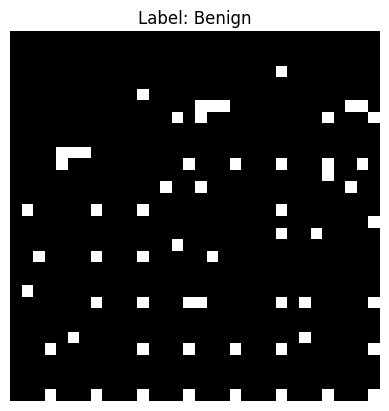

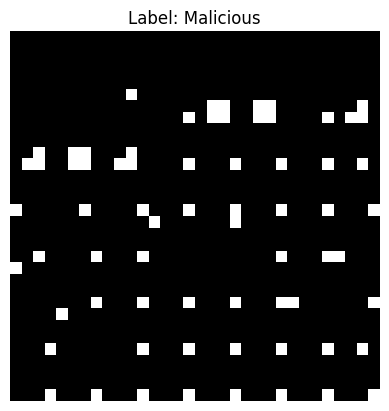

In [110]:
# plot a benign image
def plot_image(image, label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()


benign_image = train_dataset[0][0]
plot_image(benign_image, "Benign")

malicious_image = train_dataset[-1][0]
plot_image(malicious_image, "Malicious")

In [ ]:
model_savepath = f"../../models/checkpoints/multi_cnn"


os.makedirs(model_savepath, exist_ok=True)

pathname_map = {
    'BinaryCNN': "bcnn",
    'BinaryCNN3': "bcnn3",
    'BinaryCNN2': "bcnn2"
}


benign_count = train_df_encoded["Label"].value_counts()[1]
malicious_count = train_df_encoded["Label"].value_counts().sum() - benign_count

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

total_samples = len(train_df_encoded)
class_counts = np.bincount(train_df_encoded["Label"])
class_weights = total_samples / (len(LE.classes_) * class_counts)

class_weights = torch.as_tensor(class_weights, dtype=torch.float32).to(device)

pos_weight, class_weights

(tensor([5.], device='cuda:0'),
 tensor([1., 1., 1., 1., 1., 1.], device='cuda:0'))

In [76]:
best_stats = {
    "bcnn" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn2" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    },
    "bcnn3" : {
        "cos": {
            "model": None,
            "history": None,
        },
        "plateau": {
            "model": None,
            "history": None,
        }
    }
}


for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__

    model_savepath_cosine = f"{model_savepath}/{pathname_map[model_name]}_ce_multi_cosine.pt"
    model_savepath_plateau = f"{model_savepath}/{pathname_map[model_name]}_ce_multi_plateau.pt"

    print(f"Training {model_name} with CosineAnnealingWarmRestarts")
    best_model_cos, history_cos = train_model_cosine(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, weights=class_weights, model_savepath=model_savepath_cosine, debug=False)
    best_stats[pathname_map[model_name]]["cos"]["model"] = best_model_cos
    best_stats[pathname_map[model_name]]["cos"]["history"] = history_cos
    print("\n\n")

    print(f"Training {model_name} with ReduceLROnPlateau")
    best_model_plateau, history_plateau = train_model_reduceonplateau(model_class, criterion_cross_entropy, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=20, device=device, weights=class_weights, model_savepath=model_savepath_plateau, debug=False)
    best_stats[pathname_map[model_name]]["plateau"]["model"] = best_model_plateau
    best_stats[pathname_map[model_name]]["plateau"]["history"] = history_plateau
    print("\n\n")

Training BinaryCNN with CosineAnnealingWarmRestarts

Epoch 1/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:39<00:00, 19.05it/s]



Loss - Train: 0.4510, Val: 0.2388
Accuracy - Train: 0.8013, Val: 0.8455

Epoch 2/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:21<00:00, 34.51it/s]



Loss - Train: 0.2630, Val: 0.2015
Accuracy - Train: 0.8721, Val: 0.8987

Epoch 3/50
--------------------------------------------------


...


Loss - Train: 0.1582, Val: 0.1659
Accuracy - Train: 0.9223, Val: 0.9164

Epoch 49/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:19<00:00, 37.88it/s]



Loss - Train: 0.1596, Val: 0.1659
Accuracy - Train: 0.9209, Val: 0.9163

Epoch 50/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:19<00:00, 37.51it/s]



Loss - Train: 0.1588, Val: 0.1658
Accuracy - Train: 0.9200, Val: 0.9164

Best model was from epoch 38 with validation loss 0.1655





Model: bcnn
ReduceLROnPlateau


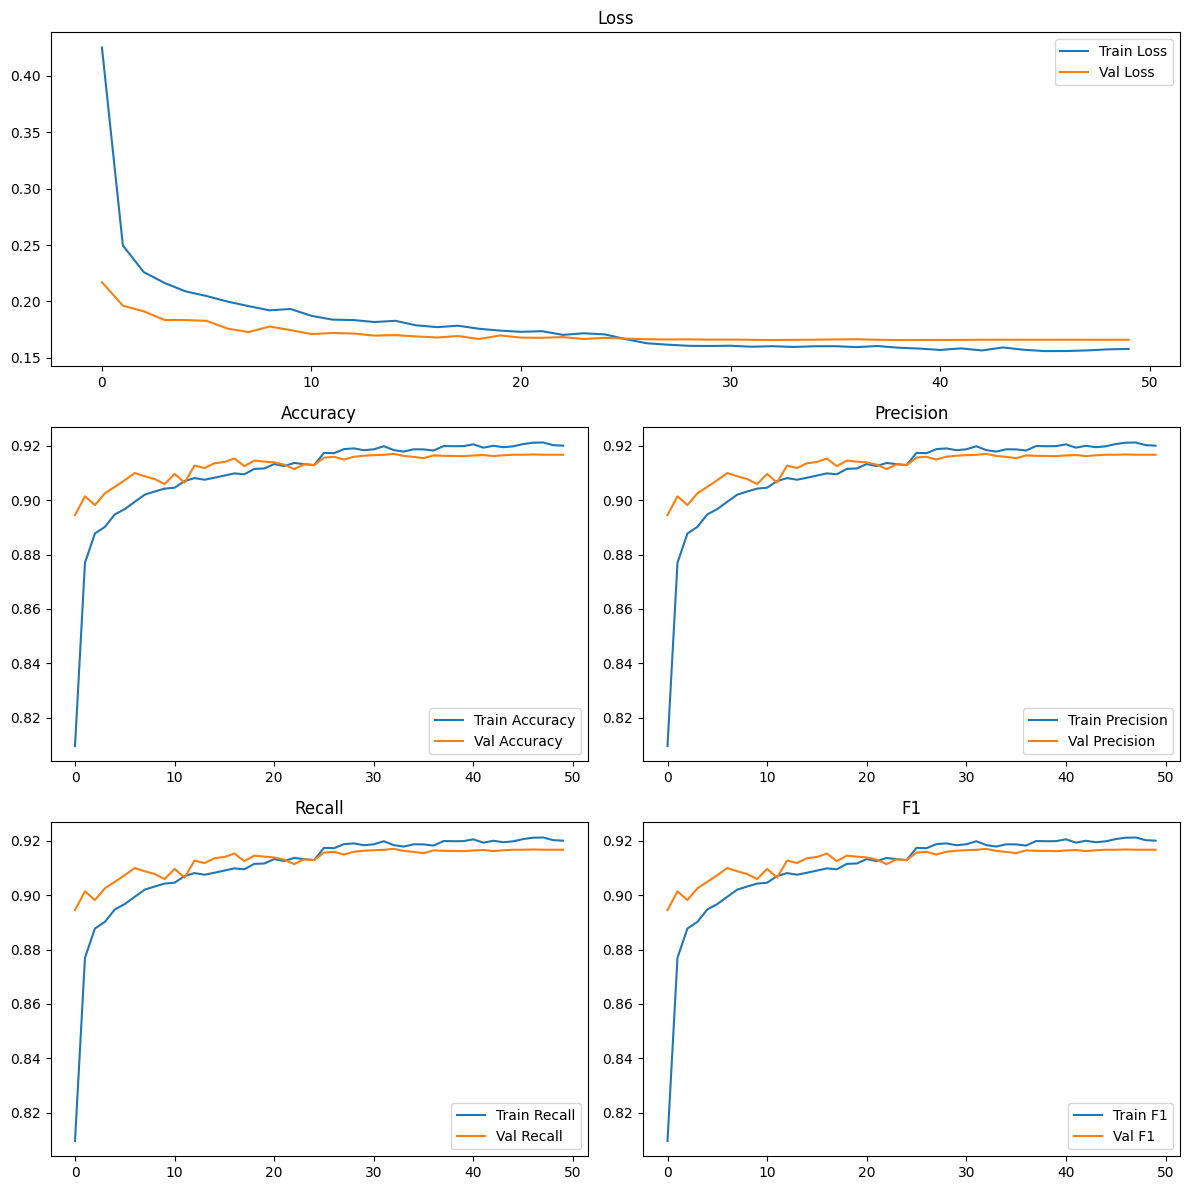




CosineAnnealingWarmRestarts


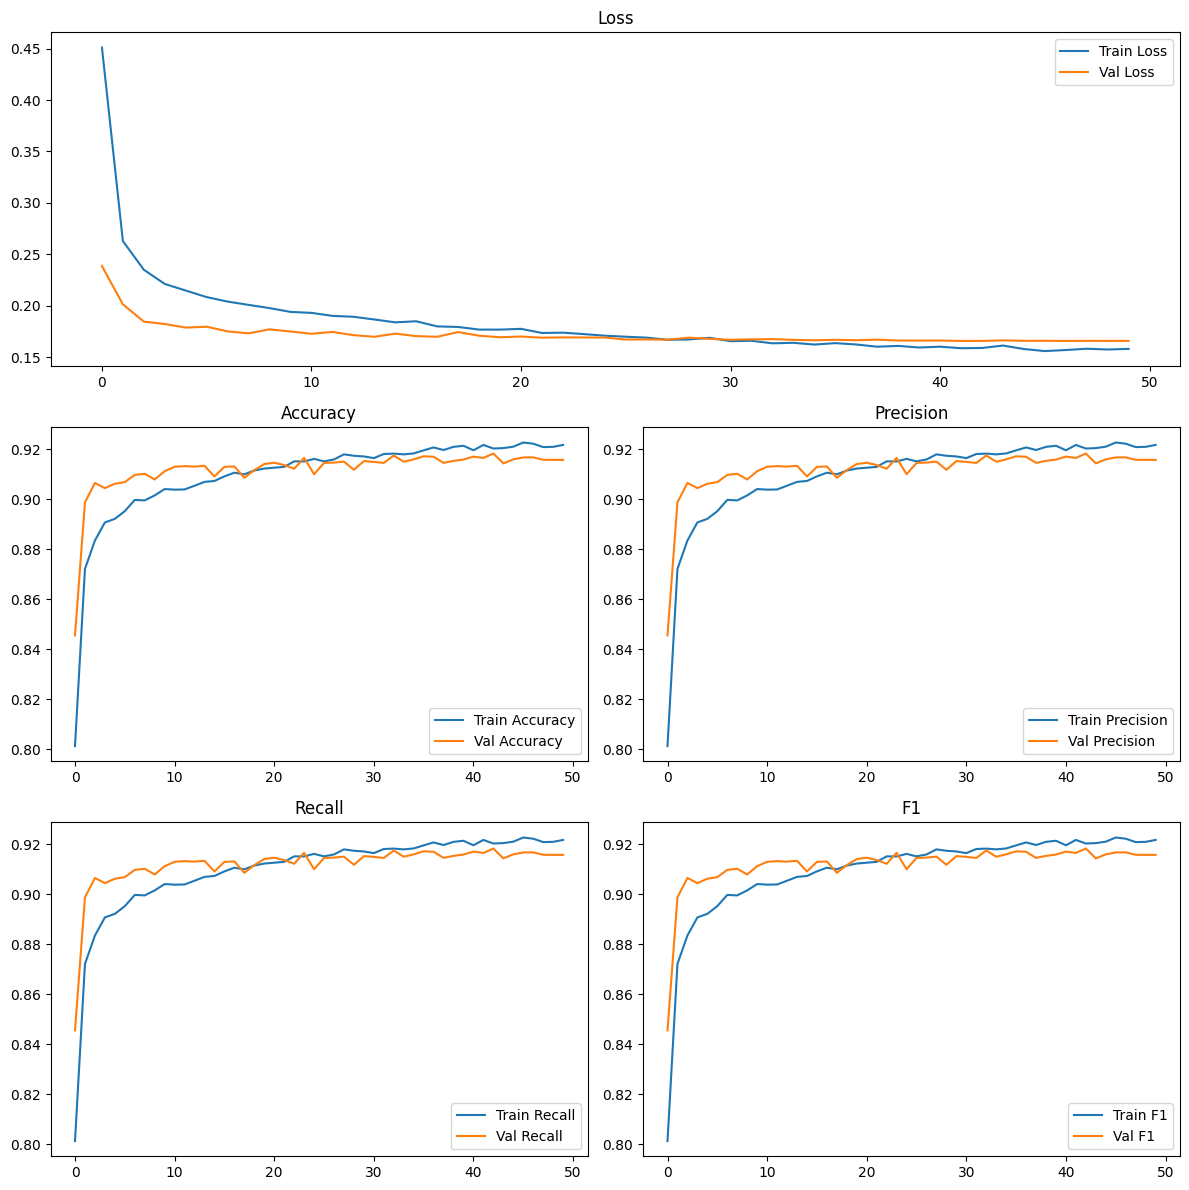




Model: bcnn2
ReduceLROnPlateau


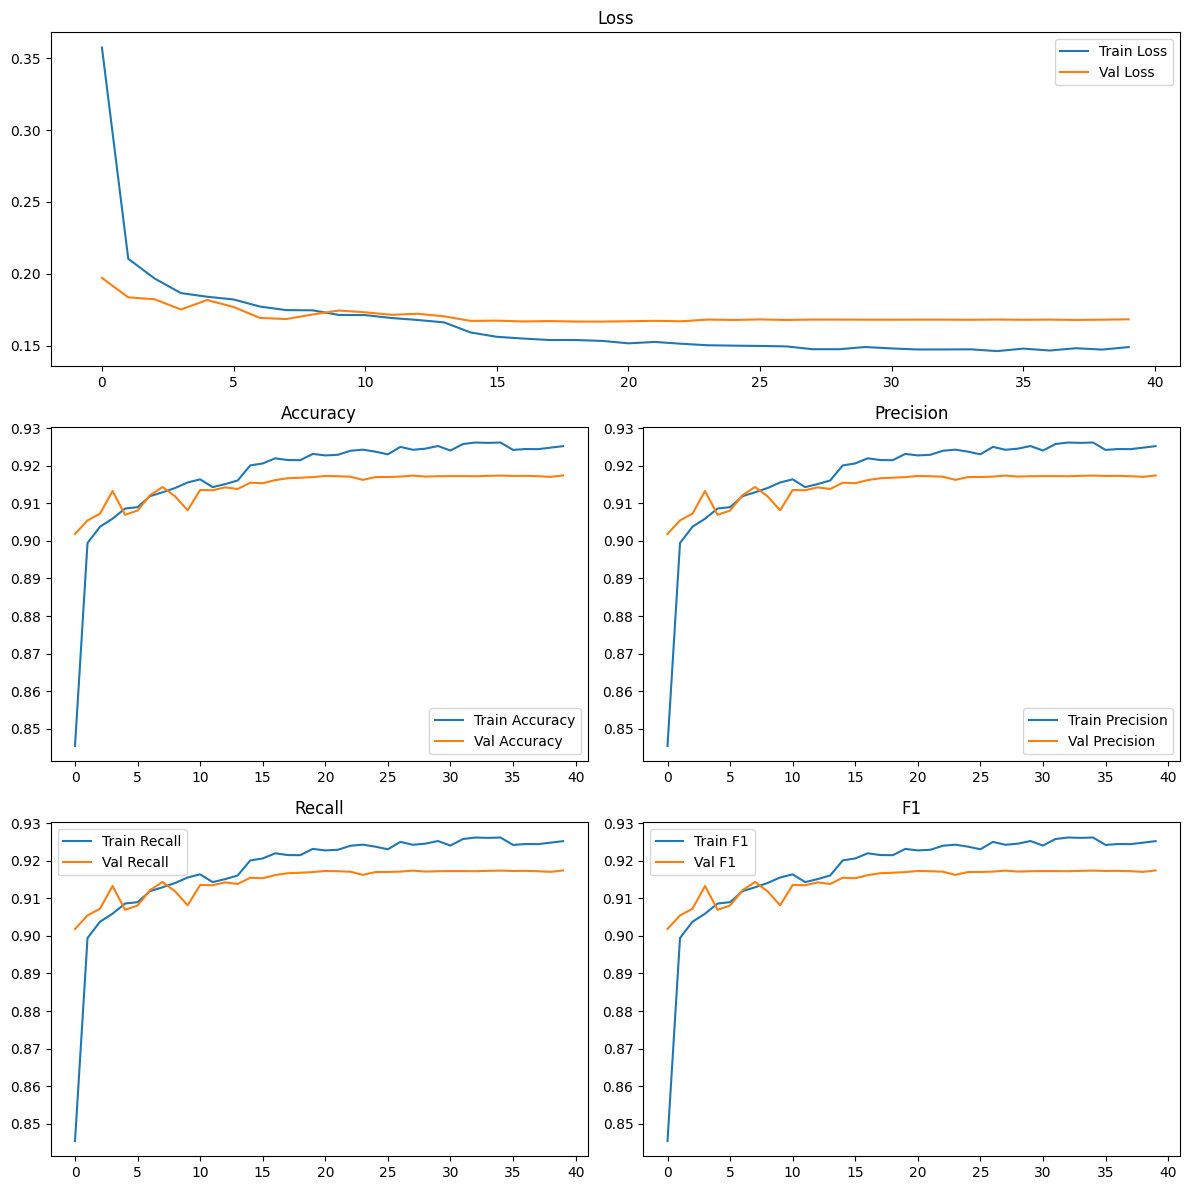




CosineAnnealingWarmRestarts


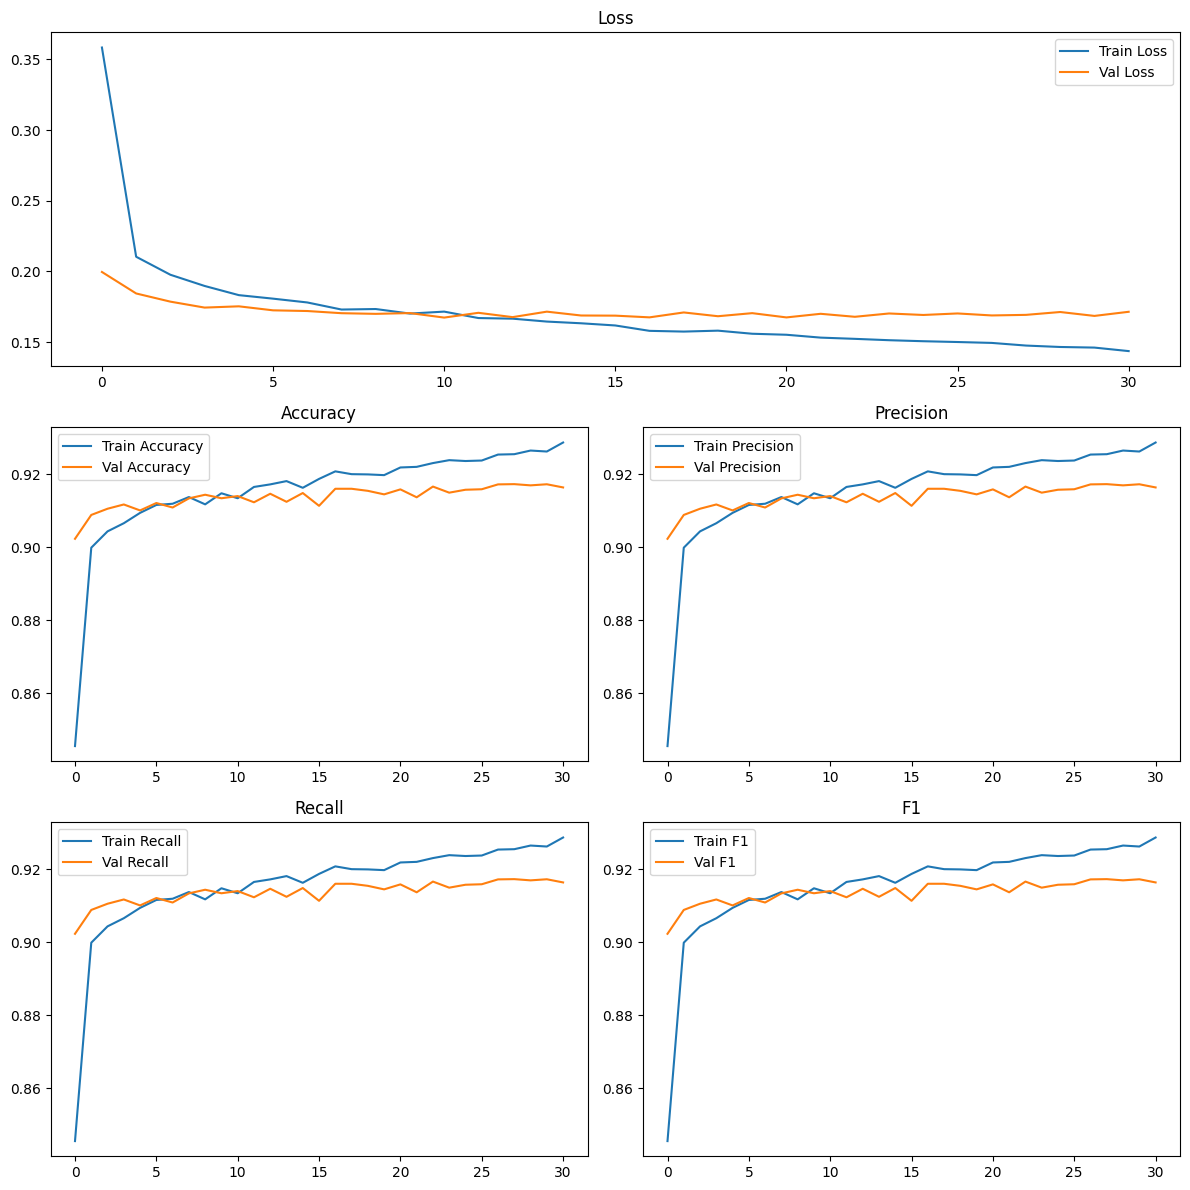




Model: bcnn3
ReduceLROnPlateau


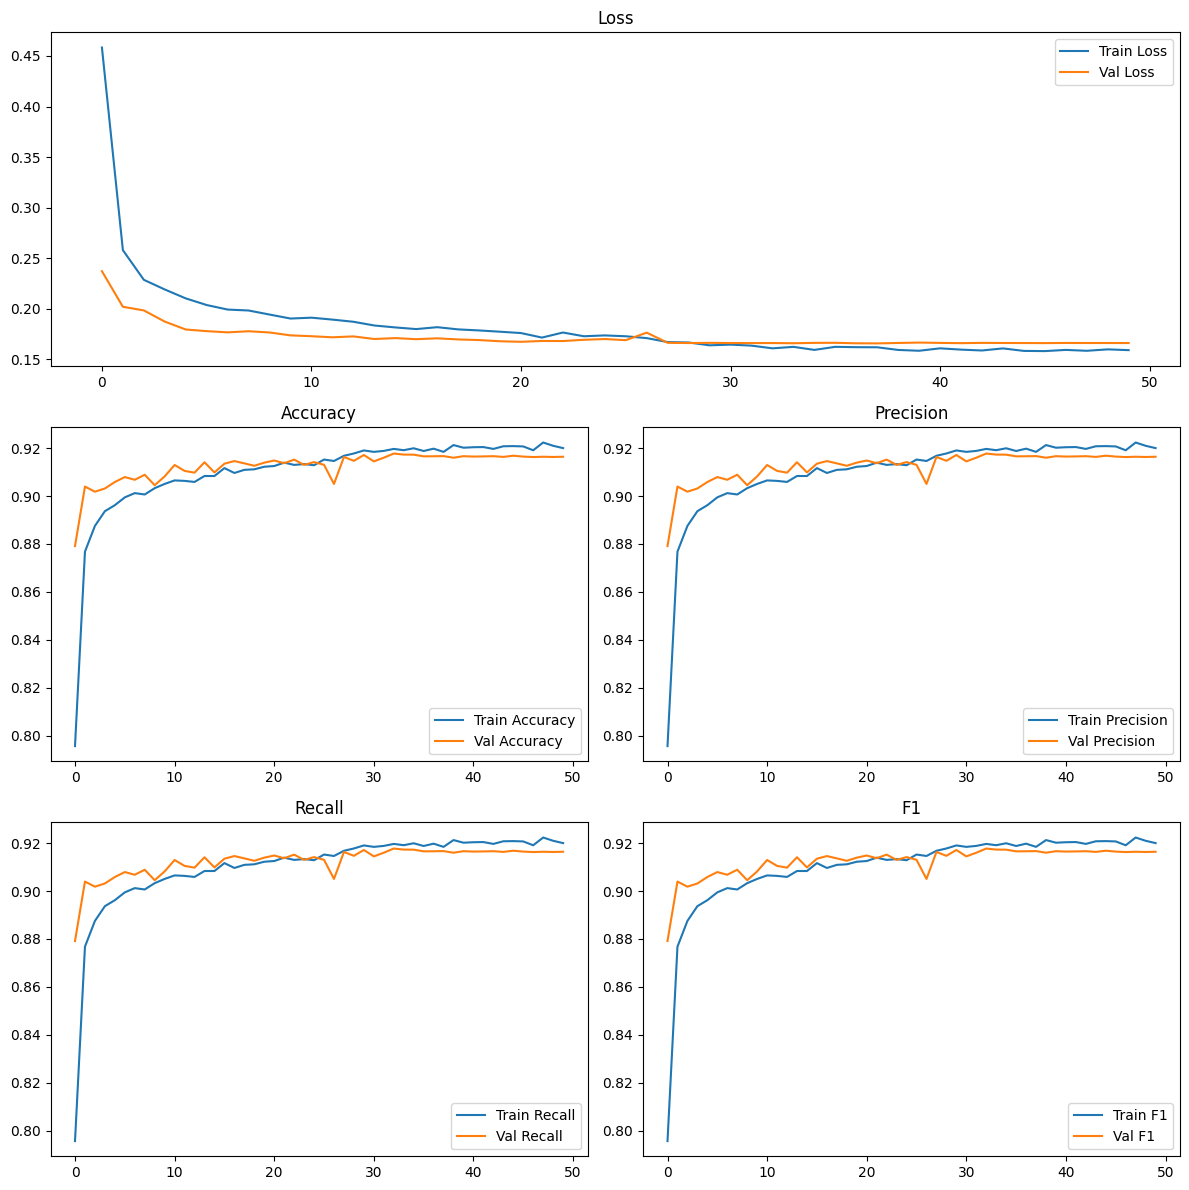




CosineAnnealingWarmRestarts


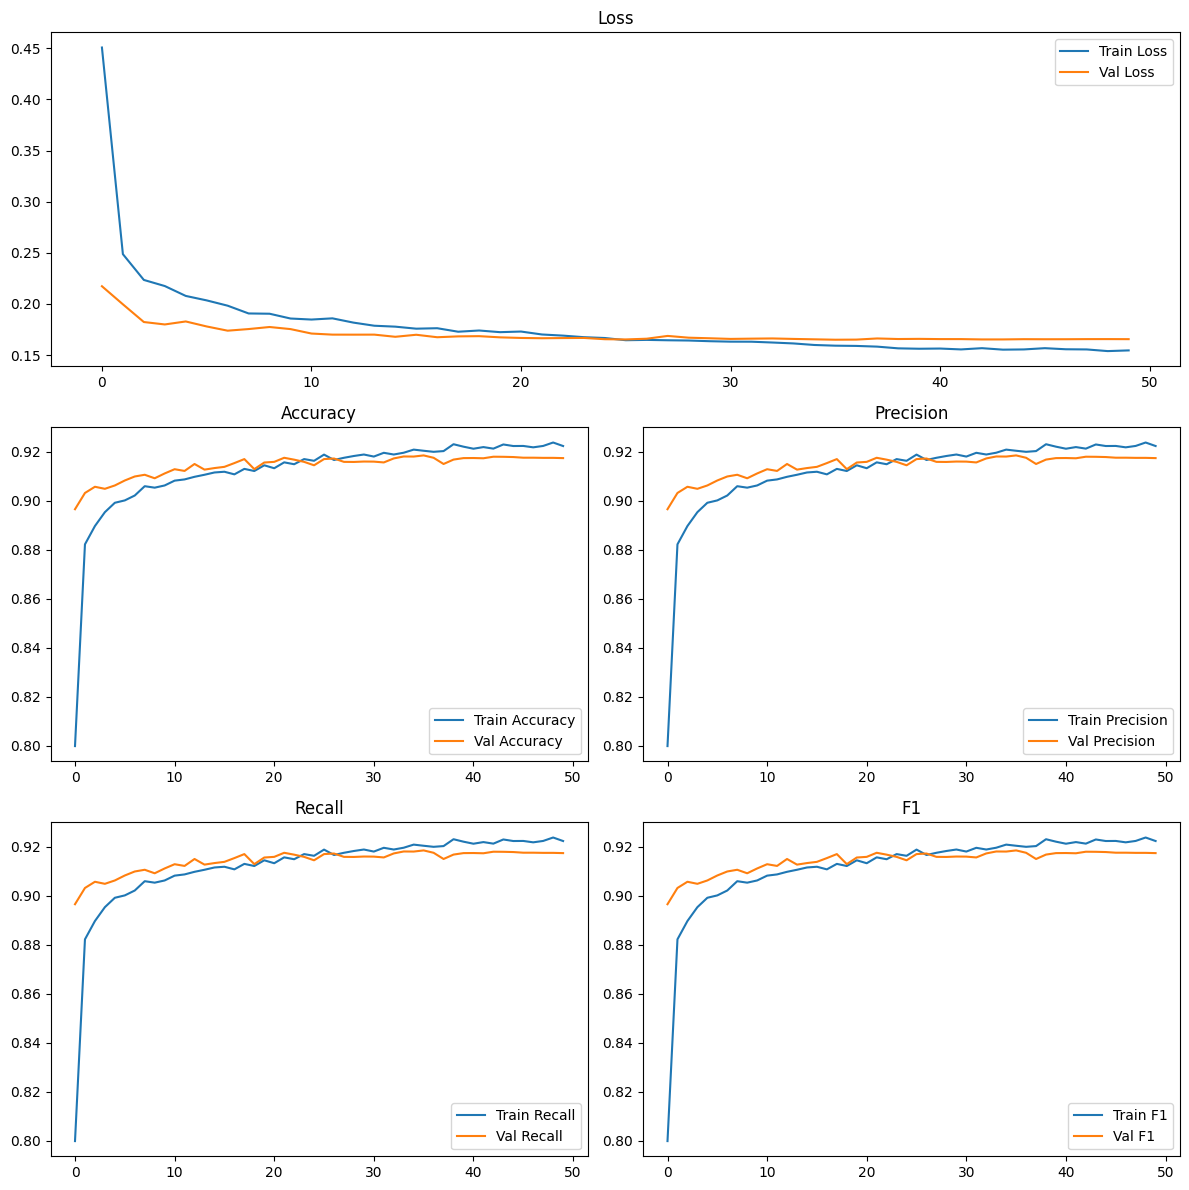

In [112]:
# plot metrics for each model
for model_name, model_stats in best_stats.items():
    print(f"Model: {model_name}")
    print("ReduceLROnPlateau")
    plot_metrics(model_stats["plateau"]["history"])
    print("\n\n")


    print("CosineAnnealingWarmRestarts")
    plot_metrics(model_stats["cos"]["history"])
    print("\n\n")

In [113]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

In [114]:
test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [115]:
from sklearn.metrics import confusion_matrix

def test_model(model, test_loader, device="cuda"):  # Changed to test_loader for clarity
    model.eval()
    preds = []
    true = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing Batches"):
            images = images.to(device)
            labels = labels.to(device)  # Keep as long tensor
            
            outputs = model(images)
            batch_preds = torch.argmax(outputs, dim=1)
            
            preds.extend(batch_preds.cpu().numpy())
            true.extend(labels.cpu().numpy())  # Labels should already be integers

    return true, preds

def test_metrics(true, preds):
    metrics = calculate_metrics(true, preds)

    accuracy = metrics["accuracy"]
    precision = metrics["precision"]
    recall = metrics["recall"]
    f1 = metrics["f1"]

    
    # confusion matrix
    cm = confusion_matrix(true, preds)

    # plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")

    plt.colorbar()

    # 1 is benign, 0 is malicious in predictions and labels

    tick_marks = np.arange(len(LE.classes_))
    plt.xticks(tick_marks, LE.classes_)
    plt.yticks(tick_marks, LE.classes_)
    plt.tight_layout()


    for i in range(len(LE.classes_)):
        for j in range(len(LE.classes_)):
            plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")



    plt.show()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1


In [116]:
# sample 12000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(2000, random_state=42)


test_data_sample["Label"].value_counts()

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

Testing BinaryCNN
CosineAnnealingWarmRestarts


Testing Batches: 100%|██████████| 300/300 [00:13<00:00, 22.69it/s]


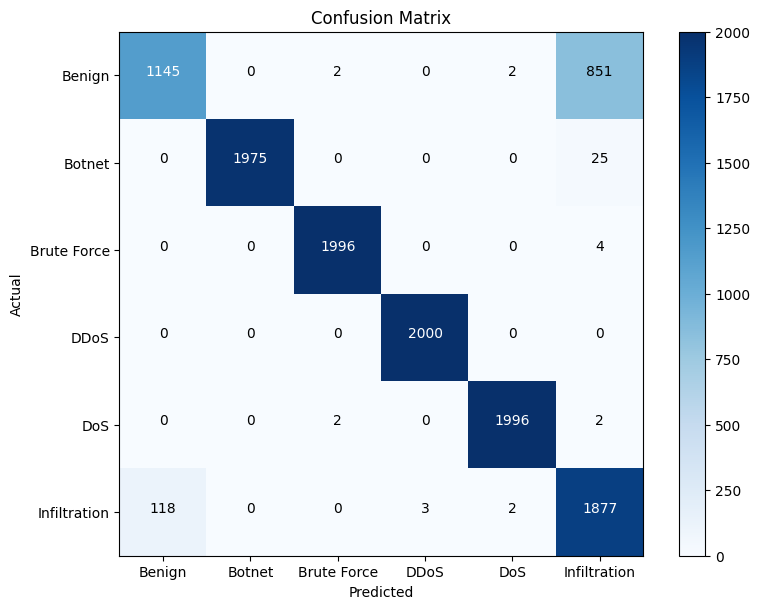

Accuracy: 0.9157
Precision: 0.9157
Recall: 0.9157
F1 Score: 0.9157



ReduceLROnPlateau


Testing Batches: 100%|██████████| 300/300 [00:08<00:00, 35.62it/s]


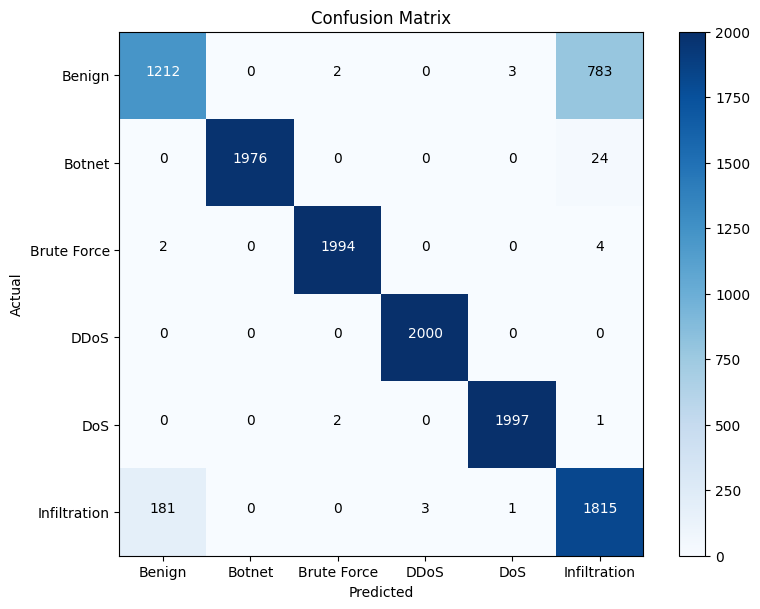

Accuracy: 0.9162
Precision: 0.9162
Recall: 0.9162
F1 Score: 0.9162



Testing BinaryCNN2
CosineAnnealingWarmRestarts


Testing Batches: 100%|██████████| 300/300 [00:08<00:00, 36.91it/s]


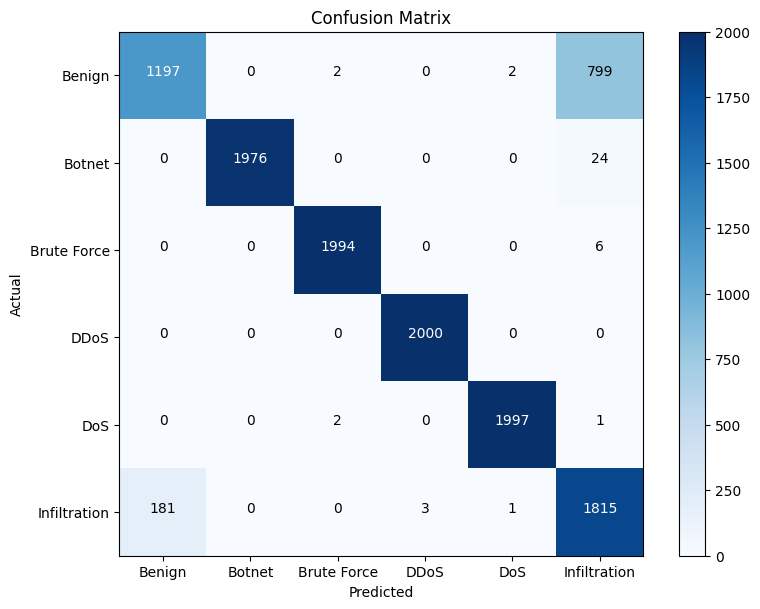

Accuracy: 0.9149
Precision: 0.9149
Recall: 0.9149
F1 Score: 0.9149



ReduceLROnPlateau


Testing Batches: 100%|██████████| 300/300 [00:08<00:00, 37.10it/s]


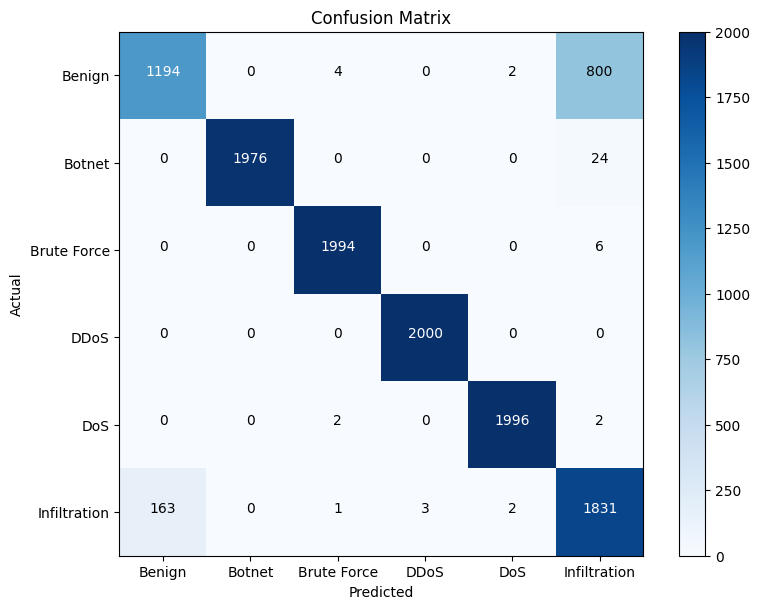

Accuracy: 0.9159
Precision: 0.9159
Recall: 0.9159
F1 Score: 0.9159



Testing BinaryCNN3
CosineAnnealingWarmRestarts


Testing Batches: 100%|██████████| 300/300 [00:08<00:00, 37.10it/s]


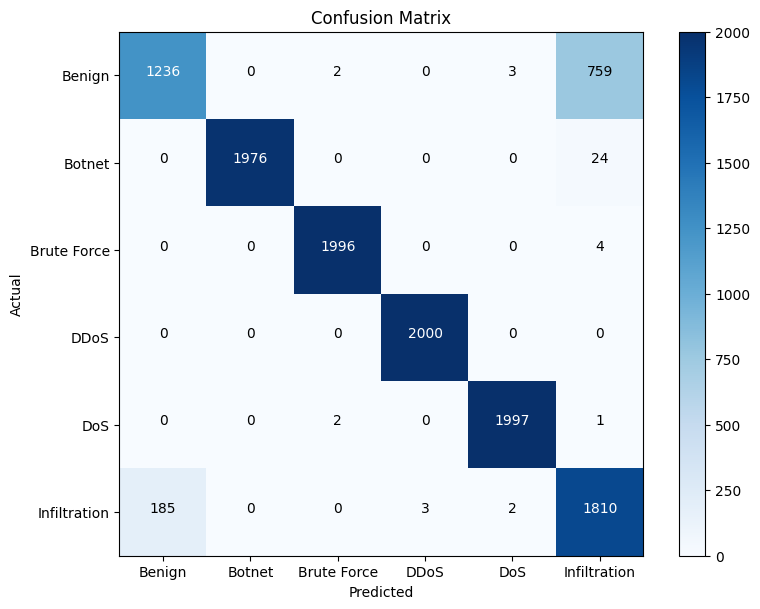

Accuracy: 0.9179
Precision: 0.9179
Recall: 0.9179
F1 Score: 0.9179



ReduceLROnPlateau


Testing Batches: 100%|██████████| 300/300 [00:08<00:00, 36.88it/s]


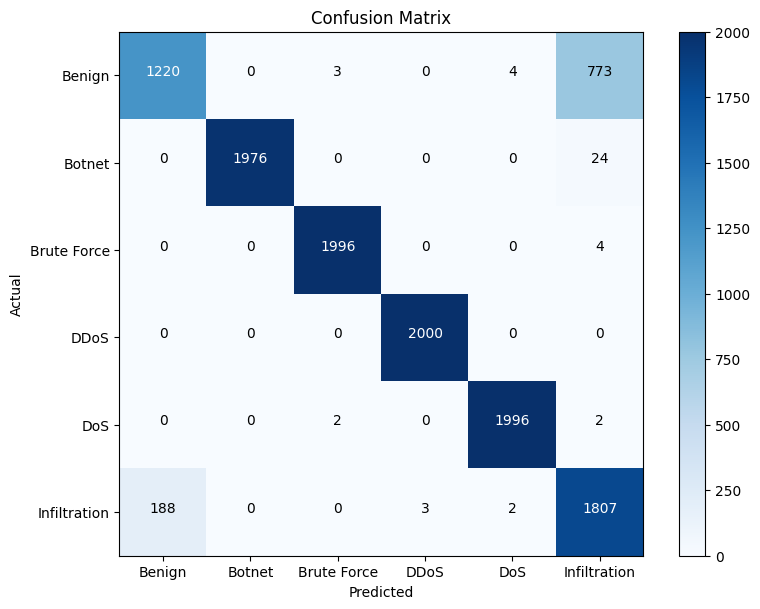

Accuracy: 0.9163
Precision: 0.9163
Recall: 0.9163
F1 Score: 0.9163





In [117]:
# model = BinaryCNN2().to(device)
# model.load_state_dict(torch.load(model_savepath, weights_only=True))


# test each model with the test data
# load model from checkpoint
# calculate metrics for each model

for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__
    print(f"Testing {model_name}")
    
    print(f"CosineAnnealingWarmRestarts")
    model = model_class(num_classes=6).to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["cos"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device=device)
    test_metrics(true, preds)
    print("\n\n")

    print(f"ReduceLROnPlateau")
    model = model_class(num_classes=6).to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["plateau"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device=device)
    test_metrics(true, preds)
    print("\n\n")
